### Part A - Image Feature Extraction and Classification

##### A.1 Read the asphalt images using OpenCV or PIL, inspect their dimensions/channels, resize them to a common size, and create grayscale representations.

In [20]:
import cv2
import os
import numpy as np

data_dir = "image_data"

images = []   #actual image data as NumPy arrays
labels = []   #the class label corresponding to each images

categories = {
    "Cracks" : 1,
    "NonCracks" : 0
}

for category, label in categories.items():
    folder_path = os.path.join(data_dir, category)  #image_data/cracks, image_data/non-cracks
    for filename in os.listdir(folder_path):   
        img_path = os.path.join(folder_path, filename)    #image_data/cracks/IMG_8404 resized_338.jpg 

        #reads the image file and converts it into a NumPy array of pixel values
        img = cv2.imread(img_path)    

        if img is None: continue

        #resize the image
        img = cv2.resize(img, (128,128))    #now each color image will have a shape if (128,128,3)

        #store the images and corresponding labels 
        images.append(img)
        labels.append(label)

print("Total images:", len(images))
print("Total labels:", len(labels))

#convert lists to the NumPy arrays
X = np.array(images)
y = np.array(labels)

print(X.shape)   #(number of images,image height,image width, color channels)
print(y.shape)


Total images: 400
Total labels: 400
(400, 128, 128, 3)
(400,)


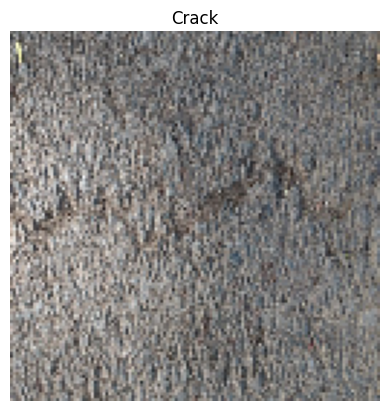

In [21]:
# Display an image and label
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(X[0], cv2.COLOR_BGR2RGB))
plt.title("Crack" if y[0] == 1 else "Non-cracked")
plt.axis("off")
plt.show()

In [22]:
print("Image:", filename)
print("Shape:", img.shape)
print("Height:", img.shape[0])
print("Width:", img.shape[1])
print("Channels:", img.shape[2])
print("-" * 30)

Image: IMG_8825 resized_448.jpg
Shape: (128, 128, 3)
Height: 128
Width: 128
Channels: 3
------------------------------


In [23]:
# Create grayscale representations
gray_images = []

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray)

X_gray = np.array(gray_images)

print("Grayscale shape:", X_gray.shape)

Grayscale shape: (400, 128, 128)


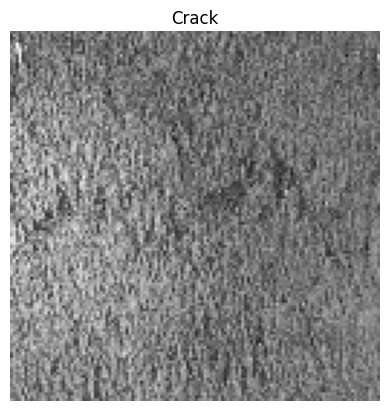

In [24]:
plt.imshow(cv2.cvtColor(X_gray[0], cv2.COLOR_BGR2RGB))
plt.title("Crack" if y[0] == 1 else "Non-cracked")
plt.axis("off")
plt.show()

##### A.2 Using NumPy, extract numerical features such as mean brightness, contrast, dark-pixel ratio, bright-pixel ratio, and related intensity statistics.

In [25]:
import pandas as pd 

DARK_THRESHOLD = 50
BRIGHT_THRESHOLD = 200

features = []

for i, img in enumerate(X_gray):
    pixels = img.flatten()  #flatten image into 1D array

    # Extract intensity features
    mean_brightness = np.mean(pixels)
    contrast = np.std(pixels)
    variance = np.var(pixels)

    dark_pixel_ratio = np.mean(pixels < DARK_THRESHOLD)
    bright_pixel_ratio = np.mean(pixels > BRIGHT_THRESHOLD)

    min_intensity = np.min(pixels)
    max_intensity = np.max(pixels)
    median_intensity = np.median(pixels)

    percentile_25 = np.percentile(pixels, 25)
    percentile_75 = np.percentile(pixels, 75)

    intensity_range = max_intensity - min_intensity
    iqr = percentile_75 - percentile_25

    # Store features for this image
    features.append({
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "variance": variance,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "percentile_25": percentile_25,
        "percentile_75": percentile_75,
        "intensity_range": intensity_range,
        "iqr": iqr,
        "label": y[i]
    })


df_features = pd.DataFrame(features)
print(df_features.head())
df_features.to_csv("asphalt_features.csv", index = False)


   mean_brightness   contrast     variance  dark_pixel_ratio  \
0       122.263977  33.070752  1093.674640          0.005859   
1       131.565186  25.482184   649.341698          0.003418   
2       121.076355  31.130490   969.107390          0.014221   
3       130.309143  27.282676   744.344433          0.002197   
4       130.993286  27.639562   763.945389          0.003357   

   bright_pixel_ratio  min_intensity  max_intensity  median_intensity  \
0            0.014465             27            247             121.0   
1            0.004456             13            252             133.0   
2            0.010498              4            237             120.0   
3            0.006592              8            251             131.0   
4            0.007751             20            252             132.0   

   percentile_25  percentile_75  intensity_range   iqr  label  
0           99.0          144.0              220  45.0      1  
1          116.0          148.0              239

In [9]:
class_summary = df_features.groupby("label").mean()

print(class_summary)

       mean_brightness   contrast     variance  dark_pixel_ratio  \
label                                                              
0           157.444093  24.398785   651.591549          0.000552   
1           144.203977  31.256302  1039.593259          0.009098   

       bright_pixel_ratio  min_intensity  max_intensity  median_intensity  \
label                                                                       
0                0.048096         67.760        248.645          157.1775   
1                0.074231         29.955        250.585          144.4250   

       percentile_25  percentile_75  intensity_range       iqr  
label                                                           
0          140.98625      173.31625          180.885  32.33000  
1          124.01000      164.83625          220.630  40.82625  


##### A.3 Use OpenCV Canny edge detection to compute edge-based features such as edge count or edge density.Create one feature row per image with the crack/non-crack label.

- Canny edge produced a binary image where white pixels represent detected edges and black pixels represent non-edge pixels
- Edge count : Total number of edge pixels
- Edge density : Proportion of edge pixels
- Edge ratio : Edge density as percentage
- Mean edge density : Average intensity of detected edge pixels in the original grayscale image

In [26]:
# Canny edge detection thresholds
LOWER_THRESHOLD = 50
UPPER_THRESHOLD = 150

edge_features = []

for i,img in enumerate(X_gray):
    edges = cv2.Canny(img, LOWER_THRESHOLD, UPPER_THRESHOLD)

    #Count total number of edge pixels (pixel value=255)
    edge_count = np.count_nonzero(edges)

    #Total number of pixels
    total_pixels = edges.size   #128x128=16384

    #Calculate edge density
    edge_density = edge_count / total_pixels    #fraction of image pixels identified as edge pixel

    #Convert edge density into a percentage
    edge_percentage = edge_density * 100

    #Calculate mean intensity of edge pixels
    edge_pixels = img[edges > 0]

    if len(edge_pixels) > 0:
        mean_edge_intensity = np.mean(edge_pixels)
    else:
        mean_edge_intensity = 0

    # Store features and corresponding label
    edge_features.append({
        "edge_count": edge_count,
        "edge_density": edge_density,
        "edge_percentage": edge_percentage,
        "mean_edge_intensity": mean_edge_intensity,
        "label": y[i]
    })

# Convert the list into a DataFrame
df_edges = pd.DataFrame(edge_features)

# Display the first five rows
print(df_edges.head())

# Check dimensions
print("Feature table shape:", df_edges.shape)

df_edges.to_csv("asphalt_edge_features.csv", index=False)

   edge_count  edge_density  edge_percentage  mean_edge_intensity  label
0        6009      0.366760        36.676025           122.650191      1
1        5915      0.361023        36.102295           130.977684      1
2        5695      0.347595        34.759521           120.697103      1
3        6078      0.370972        37.097168           130.419381      1
4        5919      0.361267        36.126709           131.256124      1
Feature table shape: (400, 5)


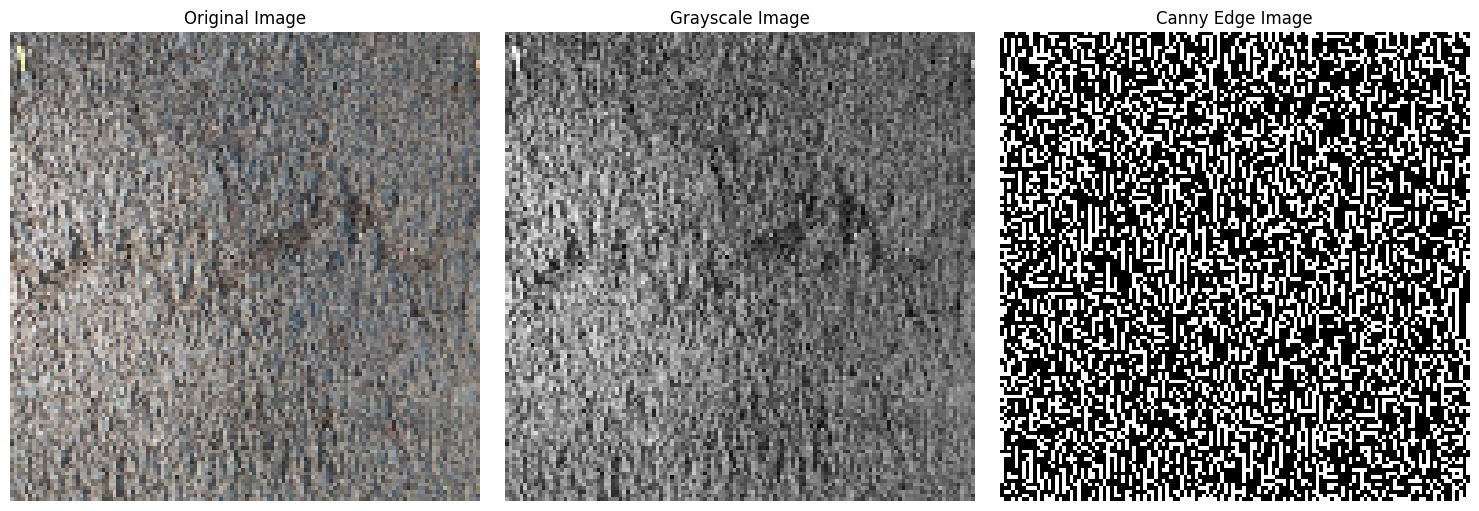

In [12]:
original = X[0]

# Get the first grayscale image
gray = X_gray[0]

# Apply Canny edge detection
edges = cv2.Canny(gray, LOWER_THRESHOLD, UPPER_THRESHOLD)

# Display all three images
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

# Grayscale image
plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

# Canny edge image
plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")

plt.tight_layout()
plt.show()

##### A.4 Train suitable traditional classifiers and evaluate using accuracy, precision, recall, F1-score, confusion matrix, training time, and prediction time.

In [ ]:
# Select feature columns, excluding the label
intensity_features = df_features.drop(columns=["label"])
edge_features_only = df_edges.drop(columns=["label"])

# Combine both sets of features
X = pd.concat([intensity_features, edge_features_only],axis=1)

y = df_features["label"].astype(int)

# Check that labels match
assert np.array_equal(
    y.to_numpy(),
    df_edges["label"].to_numpy()
), "Labels do not match!"

print("Feature shape:", X.shape)
print("Label shape:", y.shape)
print("Class distribution:\n", y.value_counts())

Feature shape: (400, 16)
Label shape: (400,)
Class distribution:
 label
1    200
0    200
Name: count, dtype: int64


In [ ]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 320
Testing samples: 80


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42)
    ),

    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf")
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# train the models
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

results = []
confusion_matrices = {}

for name, model in models.items():

    #training time
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()
    training_time = end_train - start_train

    #testing time
    start_predict = time.perf_counter()
    y_pred = model.predict(X_test)
    end_predict = time.perf_counter()
    testing_time = end_predict - start_predict

    #calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, zero_division=0)

    recall = recall_score(y_test, y_pred, zero_division=0)

    f1 = f1_score(y_test, y_pred, zero_division=0)

    #confusion matrix
    cm = confusion_matrix(
        y_test, y_pred, labels=[0, 1]
    )
    confusion_matrices[name] = cm

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Training Time (s)": training_time,
        "Prediction Time (s)": testing_time,
        "Prediction Time (ms/image)": (
            testing_time / len(X_test) * 1000
        )
    })

    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    print("Training time:", round(training_time, 4), "seconds")
    print("Prediction time:", round(testing_time, 4), "seconds")
    print("Confusion matrix:\n", cm)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Non-cracked", "Cracked"],
        zero_division=0
    ))





===== Logistic Regression =====
Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1-score: 0.95
Training time: 0.0664 seconds
Prediction time: 0.0024 seconds
Confusion matrix:
 [[38  2]
 [ 2 38]]

Classification Report:
              precision    recall  f1-score   support

 Non-cracked       0.95      0.95      0.95        40
     Cracked       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



C:\Users\SOFT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\SOFT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
 


===== KNN =====
Accuracy: 0.95
Precision: 0.9286
Recall: 0.975
F1-score: 0.9512
Training time: 0.0081 seconds
Prediction time: 0.4771 seconds
Confusion matrix:
 [[37  3]
 [ 1 39]]

Classification Report:
              precision    recall  f1-score   support

 Non-cracked       0.97      0.93      0.95        40
     Cracked       0.93      0.97      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80


===== SVM =====
Accuracy: 0.9375
Precision: 0.907
Recall: 0.975
F1-score: 0.9398
Training time: 0.0109 seconds
Prediction time: 0.0028 seconds
Confusion matrix:
 [[36  4]
 [ 1 39]]

Classification Report:
              precision    recall  f1-score   support

 Non-cracked       0.97      0.90      0.94        40
     Cracked       0.91      0.97      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94 

In [ ]:
results_df = pd.DataFrame(results)

# Sort by F1-score
results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
)

print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-score  Training Time (s)  Prediction Time (s)  Prediction Time (ms/image)
                KNN    0.9500   0.928571   0.975  0.951220           0.008126             0.477122                    5.964022
Logistic Regression    0.9500   0.950000   0.950  0.950000           0.066421             0.002421                    0.030267
                SVM    0.9375   0.906977   0.975  0.939759           0.010877             0.002826                    0.035327
      Random Forest    0.9000   0.900000   0.900  0.900000           0.347590             0.104975                    1.312188


**KNN**
- KNN achieved 95% accuracy, 97.5% recall, and a 95.12% F1-score. Its recall indicates that it detected a high proportion of actual cracked images. However, its prediction time was the longest at approximately 5.96 milliseconds per image

**Logistic Regression**
- Logistic Regression achieved 95% accuracy, 95% precision, 95% recall, and a 95% F1-score. Its prediction time was approximately 0.03 milliseconds per image, making it computationally efficient for this test.

**SVM**
- SVM achieved 93.75% accuracy and 97.5% recall. Its high recall indicates that it detected most of the cracked images, but its lower precision suggests more false-positive predictions than Logistic Regression.

**Random Forest**
- Random Forest achieved 90% accuracy, precision, recall, and F1-score. It also had the longest training time, approximately 0.35 seconds.

### Part B - Text Vectorization and Spam Classification

In [1]:
import pandas as pd

df = pd.read_csv("emails.csv")
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
print(df.shape)
print(df.columns)

(5172, 3002)
Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)


In [4]:
print(df.Prediction.value_counts())

Prediction
0    3672
1    1500
Name: count, dtype: int64


In [6]:
word_cols = [c for c in df.columns if c not in ("Email No.", "Prediction")]

#drop duplicates
before = len(df)
df = df.drop_duplicates(subset=word_cols).reset_index(drop=True)
print(f"\nDuplicates removed: {before - len(df)} (remaining: {len(df)})")


Duplicates removed: 541 (remaining: 4631)


In [8]:
#Train-test split
from sklearn.model_selection import train_test_split

X = df[word_cols].to_numpy()
y = df['Prediction'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [10]:
import time
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

def evaluate(name, model, Xtr, Xte):
    t0 = time.perf_counter()
    model.fit(Xtr, y_train)
    train_t = time.perf_counter() - t0
 
    t0 = time.perf_counter()
    pred = model.predict(Xte)
    pred_t = time.perf_counter() - t0
 
    print(f"\n{name}")
    print(f"  Accuracy {accuracy_score(y_test, pred):.4f} | "
          f"Precision {precision_score(y_test, pred):.4f} | "
          f"Recall {recall_score(y_test, pred):.4f} | "
          f"F1 {f1_score(y_test, pred):.4f}")
    print(f"  Train {train_t:.4f}s | Predict {pred_t:.4f}s")
    print("  Confusion matrix [[TN FP] [FN TP]]:")
    print(confusion_matrix(y_test, pred))
 
evaluate("MultinomialNB (raw counts)", MultinomialNB(alpha=1.0), X_train, X_test)
evaluate("LogisticRegression (raw counts)", LogisticRegression(max_iter=1000), X_train, X_test)


MultinomialNB (raw counts)
  Accuracy 0.9515 | Precision 0.8946 | Recall 0.9589 | F1 0.9256
  Train 0.3704s | Predict 0.0797s
  Confusion matrix [[TN FP] [FN TP]]:
[[602  33]
 [ 12 280]]

LogisticRegression (raw counts)
  Accuracy 0.9741 | Precision 0.9558 | Recall 0.9623 | F1 0.9590
  Train 14.3466s | Predict 0.0251s
  Confusion matrix [[TN FP] [FN TP]]:
[[622  13]
 [ 11 281]]


In [11]:
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
coefs = pd.Series(lr.coef_[0], index=word_cols).sort_values(ascending=False)
print("\nTop 10 words pushing toward spam:\n", coefs.head(10).round(3))
print("\nTop 10 words pushing toward non-spam:\n", coefs.tail(10).round(3))


Top 10 words pushing toward spam:
 men       0.867
pt        0.780
http      0.774
remove    0.723
my        0.720
ali       0.610
want      0.610
mo        0.602
move      0.596
pain      0.594
dtype: float64

Top 10 words pushing toward non-spam:
 image      -0.740
tm         -0.741
pm         -0.744
hpl        -0.819
neon       -0.832
deal       -0.900
sitara     -0.908
attached   -0.933
love       -0.956
enron      -1.179
dtype: float64


- Logistic regression is a better model on raw counts. It made only 13 false positive(non-spam marked as spam) and 11 false negative(spam marked as non-spam) on test set
- It takes 14s training time because the matrix is dense and counts are unscaled


### Part C : Improve the Representation

##### Logistic regression in Part B takes 14s for training

In [15]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("emails.csv")
feature_cols = [c for c in df.columns if c not in ("Email No.", "Prediction")]
df = df.drop_duplicates(subset=feature_cols).reset_index(drop=True)

X = df[feature_cols].to_numpy()      # dense counts
y = df["Prediction"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline
pipe = Pipeline([
    ("sparse", FunctionTransformer(csr_matrix, accept_sparse=True)),  # dense -> sparse
    ("log1p",  FunctionTransformer(np.log1p, accept_sparse=True)),    # compress large counts
    ("scale",  MaxAbsScaler()),                                       # scale each word to [0, 1]
    ("clf",    LogisticRegression(C=1.0, max_iter=1000)),             # classifier
])

t0 = time.perf_counter()
pipe.fit(X_train, y_train)
train_t = time.perf_counter() - t0
 
t0 = time.perf_counter()
pred = pipe.predict(X_test)
pred_t = time.perf_counter() - t0

print(classification_report(y_test, pred, target_names=["non-spam", "spam"], digits=4))
print(confusion_matrix(y_test, pred))
print(f"  Train {train_t:.4f}s | Predict {pred_t:.4f}s")

              precision    recall  f1-score   support

    non-spam     0.9843    0.9843    0.9843       635
        spam     0.9658    0.9658    0.9658       292

    accuracy                         0.9784       927
   macro avg     0.9750    0.9750    0.9750       927
weighted avg     0.9784    0.9784    0.9784       927

[[625  10]
 [ 10 282]]
  Train 0.2330s | Predict 0.0387s


- sparse converts the dense array to a sparse csr_matrix. It sits inside the pipeline so we can pass a normal NumPy array to fit and predict, and it is applied to any new data automatically.
- log1p applies log(1 + count) to each value. Zeros stay zero, and large counts are compressed so one word repeated 100 times doesn't dominate.
- scale (MaxAbsScaler) divides each word's column by its largest absolute value in the training data, so every feature lies between 0 and 1. It doesn't shift the values, so the zeros stay zeros and the matrix stays sparse.
- clf is logistic regression. C is the inverse regularization strength (smaller means stronger regularization), and max_iter is the iteration limit for the optimizer.

### Comparison
- Applying sparse storage, a log1p transform, and MaxAbs scaling reduced logistic regression training time from 14.3 s to 0.23 s (about 60× faster) while slightly improving F1 from 0.959 to 0.966, and reduced test errors from 24 to 20. Prediction time was similar for both (tens of milliseconds).